## DSA210 (14 April) — Data Collection, EDA & Hypothesis Tests

This notebook reproduces the **full pipeline step-by-step**:
- Load `reddit_wsb.csv`
- Clean/parse timestamps
- Extract ticker mentions (GME/AMC/BB)
- Aggregate to daily time series
- Enrich with daily market data via `yfinance`
- Join Reddit + market data
- EDA plots
- Hypothesis tests (Mann–Whitney U, Spearman)

Outputs are also saved under `outputs/` for the report.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
import yfinance as yf

sns.set_theme(style="whitegrid")

PROJECT_DIR = Path(".")
REDDIT_CSV = PROJECT_DIR / "reddit_wsb.csv"
OUT_DIR = PROJECT_DIR / "outputs"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
DATA_DIR = PROJECT_DIR / "data"

for p in [OUT_DIR, FIG_DIR, TABLE_DIR, DATA_DIR]:
    p.mkdir(parents=True, exist_ok=True)

TICKERS = ["GME", "AMC", "BB"]

print("Ready.")

Ready.


## 1) Load data

In [2]:
usecols = ["title", "score", "created", "body", "timestamp"]
reddit = pd.read_csv(REDDIT_CSV, usecols=usecols, low_memory=False)

reddit["score"] = pd.to_numeric(reddit["score"], errors="coerce")
reddit["created"] = pd.to_numeric(reddit["created"], errors="coerce")

print("rows:", len(reddit))
reddit.head()

rows: 53187


,title,score,created,body,timestamp
0,"It's not about the money, it's about sending a...",55,1.611863e+09,NaN,2021-01-28 21:37:41
1,Math Professor Scott Steiner says the numbers ...,110,1.611862e+09,NaN,2021-01-28 21:32:10
2,Exit the system,0,1.611862e+09,The CEO of NASDAQ pushed to halt trading “to g...,2021-01-28 21:30:35
3,NEW SEC FILING FOR GME! CAN SOMEONE LESS RETAR...,29,1.611862e+09,NaN,2021-01-28 21:28:57
4,"Not to distract from GME, just thought our AMC...",71,1.611862e+09,NaN,2021-01-28 21:26:56


## 2) Timestamp cleaning

We prefer `created` (Unix epoch seconds). If it is missing, we fall back to parsing the `timestamp` string. Then we build a daily key (`date`) for aggregation.

In [3]:
dt_created = pd.to_datetime(reddit["created"], unit="s", utc=True, errors="coerce")
dt_ts = pd.to_datetime(reddit["timestamp"], utc=True, errors="coerce")
reddit["dt_utc"] = dt_created.fillna(dt_ts)

reddit = reddit[reddit["dt_utc"].notna()].copy()
reddit["date"] = reddit["dt_utc"].dt.floor("D").dt.tz_localize(None)  # daily key

print("date range:", reddit["date"].min(), "->", reddit["date"].max())
reddit[["created", "timestamp", "dt_utc", "date"]].head()

date range: 2020-09-29 00:00:00 -> 2021-08-16 00:00:00


,created,timestamp,dt_utc,date
0,1.611863e+09,2021-01-28 21:37:41,2021-01-28 19:37:41+00:00,2021-01-28
1,1.611862e+09,2021-01-28 21:32:10,2021-01-28 19:32:10+00:00,2021-01-28
2,1.611862e+09,2021-01-28 21:30:35,2021-01-28 19:30:35+00:00,2021-01-28
3,1.611862e+09,2021-01-28 21:28:57,2021-01-28 19:28:57+00:00,2021-01-28
4,1.611862e+09,2021-01-28 21:26:56,2021-01-28 19:26:56+00:00,2021-01-28


## 3) Extract ticker mentions (GME/AMC/BB)

We scan `title + body` with a regex that matches `$GME` or `GME` (uppercase 1–5 letters), then count daily mentions per ticker.

In [4]:
TICKER_RE = re.compile(r"(?<![A-Z0-9$])\$?([A-Z]{1,5})(?![A-Z0-9])")

def extract_mentions(text: str, ticker_set: set[str]) -> set[str]:
    found = set(m.group(1) for m in TICKER_RE.finditer(text))
    return found & ticker_set

ticker_set = set(TICKERS)
reddit["title"] = reddit["title"].fillna("").astype(str)
reddit["body"] = reddit["body"].fillna("").astype(str)
reddit["text"] = (reddit["title"] + " " + reddit["body"]).str.upper()
reddit["mentioned"] = reddit["text"].map(lambda t: extract_mentions(t, ticker_set))

for t in TICKERS:
    reddit[f"m_{t}"] = reddit["mentioned"].map(lambda s, tt=t: int(tt in s))

reddit[["title", "score", "mentioned", "m_GME", "m_AMC", "m_BB"]].head(10)

,title,score,mentioned,m_GME,m_AMC,m_BB
0,"It's not about the money, it's about sending a...",55,{},0,0,0
1,Math Professor Scott Steiner says the numbers ...,110,{},0,0,0
2,Exit the system,0,{GME},1,0,0
3,NEW SEC FILING FOR GME! CAN SOMEONE LESS RETAR...,29,{GME},1,0,0
4,"Not to distract from GME, just thought our AMC...",71,"{GME, AMC}",1,1,0
5,WE BREAKING THROUGH,405,{},0,0,0
6,SHORT STOCK DOESN'T HAVE AN EXPIRATION DATE,317,{GME},1,0,0
7,THIS IS THE MOMENT,405,"{GME, BB}",1,0,1
8,Currently Holding AMC and NOK - Is it retarded...,200,"{GME, AMC}",1,1,0
9,I have nothing to say but BRUH I am speechless...,291,{},0,0,0


## 4) Aggregate to daily time series

In [5]:
agg = {
    "score": ["count", "sum", "mean"],
    "m_GME": ["sum"],
    "m_AMC": ["sum"],
    "m_BB": ["sum"],
}

daily = reddit.groupby("date", as_index=True).agg(agg)
daily.columns = ["_".join(c).strip("_") for c in daily.columns.to_flat_index()]

daily = daily.rename(
    columns={
        "score_count": "posts",
        "score_sum": "score_sum",
        "score_mean": "score_mean",
        "m_GME_sum": "mentions_GME",
        "m_AMC_sum": "mentions_AMC",
        "m_BB_sum": "mentions_BB",
    }
).sort_index()

daily.to_csv(TABLE_DIR / "daily_reddit_aggregates.csv")
daily.head()

,posts,score_sum,score_mean,mentions_GME,mentions_AMC,mentions_BB
date,,,,,,
2020-09-29,1,4,4.000000,0,0,0
2021-01-28,8447,1178729,139.544098,2308,1467,782
2021-01-29,8938,7143183,799.192549,2936,1093,574
2021-01-30,1044,6327616,6060.934866,410,92,45
2021-01-31,895,4894640,5468.871508,385,87,46


## 5) Enrich with market data (yfinance)

We download daily OHLCV for each ticker for the same date range and cache it under `data/`.

In [6]:
start = str(daily.index.min().date())
end = str((daily.index.max() + pd.Timedelta(days=2)).date())

print("market date window:", start, "->", end)

def _flatten_yf_columns(df: pd.DataFrame) -> pd.DataFrame:
    # yfinance may return MultiIndex columns even for a single ticker.
    # Example: ('Close','GME'), ('Volume','GME'), ...
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = df.columns.get_level_values(0)
    return df

def fetch_market(ticker: str, refresh: bool = False) -> pd.DataFrame:
    cache = DATA_DIR / f"market_{ticker}.csv"

    if cache.exists() and not refresh:
        # handle older cached files that may contain multi-row headers
        try:
            m = pd.read_csv(cache)
            if "Date" not in m.columns:
                raise ValueError("unexpected cache format")
        except Exception:
            m = pd.read_csv(cache, header=[0, 1])
            if isinstance(m.columns, pd.MultiIndex):
                m.columns = [a if a not in ("Date", "Datetime") else "Date" for a, _ in m.columns.to_list()]
    else:
        data = yf.download(ticker, start=start, end=end, interval="1d", auto_adjust=False, progress=False)
        if data.empty:
            raise RuntimeError(f"No market data for {ticker}")
        data = _flatten_yf_columns(data)
        m = data.reset_index()
        m.to_csv(cache, index=False)

    # If cache was read with MultiIndex columns, flatten again.
    if isinstance(m.columns, pd.MultiIndex):
        m = m.copy()
        m.columns = [a if a not in ("Date", "Datetime") else "Date" for a, _ in m.columns.to_list()]

    m["Date"] = pd.to_datetime(m["Date"], utc=True, errors="coerce").dt.floor("D").dt.tz_localize(None)
    m = m.rename(columns={"Date": "date"})

    m["return_close"] = m["Close"].pct_change()
    m["abs_return"] = m["return_close"].abs()
    m["hl_range"] = (m["High"] - m["Low"]) / m["Close"]

    keep = ["date", "Open", "High", "Low", "Close", "Adj Close", "Volume", "return_close", "abs_return", "hl_range"]
    return m[keep].sort_values("date")

markets = {t: fetch_market(t, refresh=True) for t in TICKERS}
for t, m in markets.items():
    print(t, m.shape, "date range:", m["date"].min(), "->", m["date"].max())

markets["GME"].head()

market date window: 2020-09-29 -> 2021-08-18


GME (223, 10) date range: 2020-09-29 00:00:00 -> 2021-08-17 00:00:00
AMC (223, 10) date range: 2020-09-29 00:00:00 -> 2021-08-17 00:00:00
BB (223, 10) date range: 2020-09-29 00:00:00 -> 2021-08-17 00:00:00


Price,date,Open,High,Low,Close,Adj Close,Volume,return_close,abs_return,hl_range
0,2020-09-29,2.5000,2.6625,2.4825,2.5875,2.5875,20950400,NaN,NaN,0.069565
1,2020-09-30,2.5625,2.6900,2.5150,2.5500,2.5500,24316000,-0.014493,0.014493,0.068627
2,2020-10-01,2.5225,2.5625,2.4225,2.4425,2.4425,18216400,-0.042157,0.042157,0.057318
3,2020-10-02,2.3450,2.4450,2.3250,2.3475,2.3475,17362000,-0.038895,0.038895,0.051118
4,2020-10-05,2.3600,2.3975,2.3125,2.3650,2.3650,11220000,0.007455,0.007455,0.035941


## 6) Join Reddit daily aggregates with market data + create next-day targets

In [7]:
joined = {}
for t in TICKERS:
    j = daily.reset_index().merge(markets[t], on="date", how="inner").sort_values("date")

    # next-day targets (leading-indicator tests)
    j["vol_next"] = j["Volume"].shift(-1)
    j["absret_next"] = j["abs_return"].shift(-1)
    j["hl_next"] = j["hl_range"].shift(-1)

    joined[t] = j
    j.to_csv(TABLE_DIR / f"joined_daily_{t}.csv", index=False)

print("joined keys:", list(joined.keys()))
joined[TICKERS[0]].head()

joined keys: ['GME', 'AMC', 'BB']


,date,posts,score_sum,score_mean,mentions_GME,mentions_AMC,mentions_BB,Open,High,Low,Close,Adj Close,Volume,return_close,abs_return,hl_range,vol_next,absret_next,hl_next
0,2020-09-29,1,4,4.000000,0,0,0,2.500000,2.662500,2.4825,2.587500,2.587500,20950400,NaN,NaN,0.069565,235263200.0,0.442894,1.915031
1,2021-01-28,8447,1178729,139.544098,2308,1467,782,66.250000,120.750000,28.0625,48.400002,48.400002,235263200,-0.442894,0.442894,1.915031,202264400.0,0.678719,0.504554
2,2021-01-29,8938,7143183,799.192549,2936,1093,574,94.927498,103.495003,62.5000,81.250000,81.250000,202264400,0.678719,0.678719,0.504554,149528800.0,0.307692,0.488889
3,2021-02-01,1154,3521109,3051.220971,400,120,59,79.139999,80.500000,53.0000,56.250000,56.250000,149528800,-0.307692,0.307692,0.488889,312732400.0,0.600000,0.930889
4,2021-02-02,1963,1023295,521.291391,576,179,34,35.189999,39.500000,18.5550,22.500000,22.500000,312732400,-0.600000,0.600000,0.930889,170794000.0,0.026778,0.304621


## 7) EDA visualizations

We save figures under `outputs/figures/` and also display them inline.

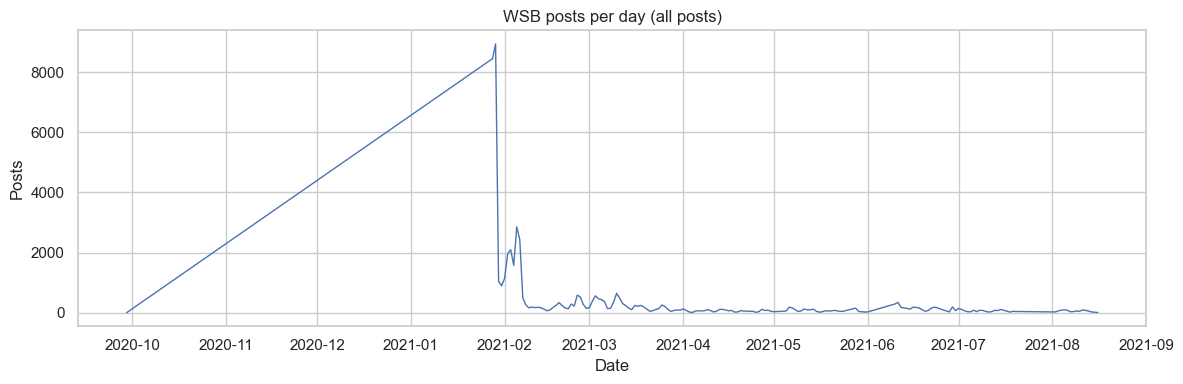

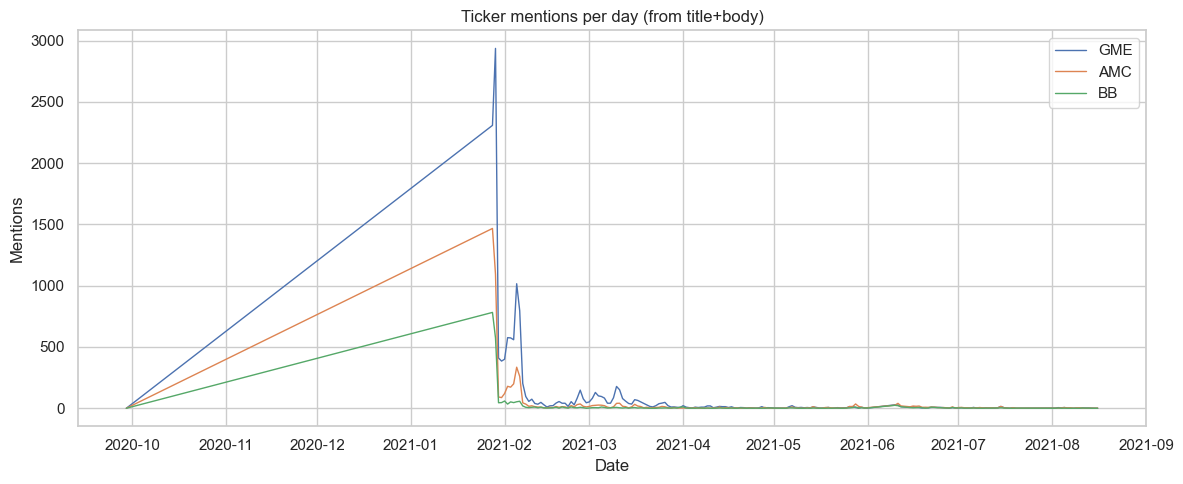

In [8]:
# Posts per day
plt.figure(figsize=(12, 4))
plt.plot(daily.index, daily["posts"], linewidth=1)
plt.title("WSB posts per day (all posts)")
plt.xlabel("Date")
plt.ylabel("Posts")
plt.tight_layout()
plt.savefig(FIG_DIR / "posts_per_day.png", dpi=160)
plt.show()

# Mentions per day
plt.figure(figsize=(12, 5))
for t in TICKERS:
    plt.plot(daily.index, daily[f"mentions_{t}"], linewidth=1, label=t)
plt.title("Ticker mentions per day (from title+body)")
plt.xlabel("Date")
plt.ylabel("Mentions")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "mentions_per_day.png", dpi=160)
plt.show()

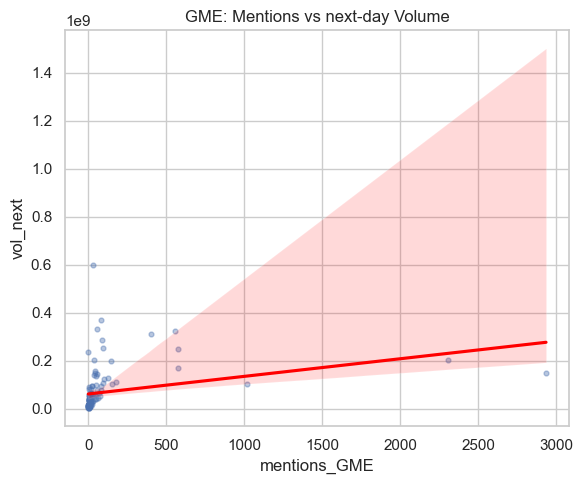

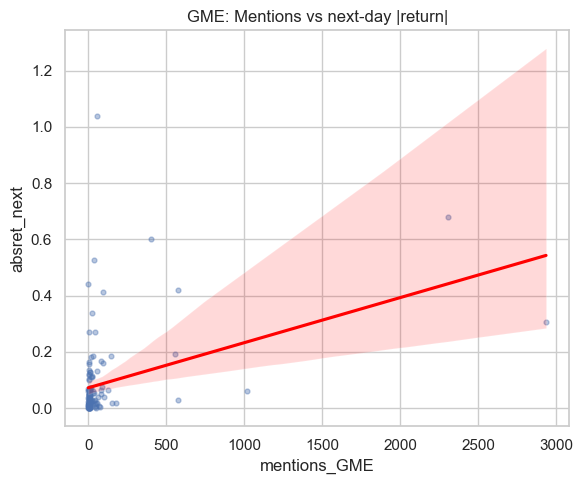

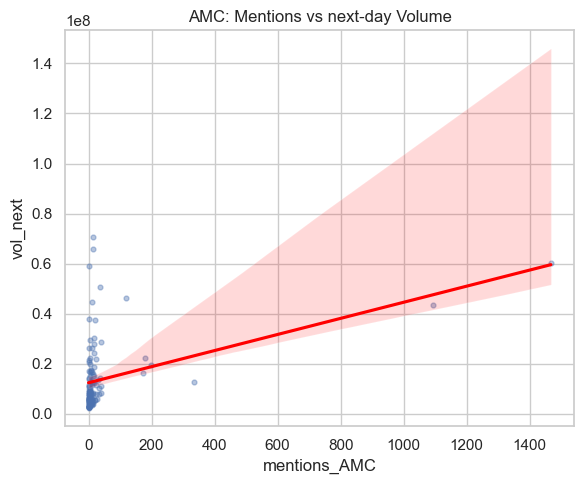

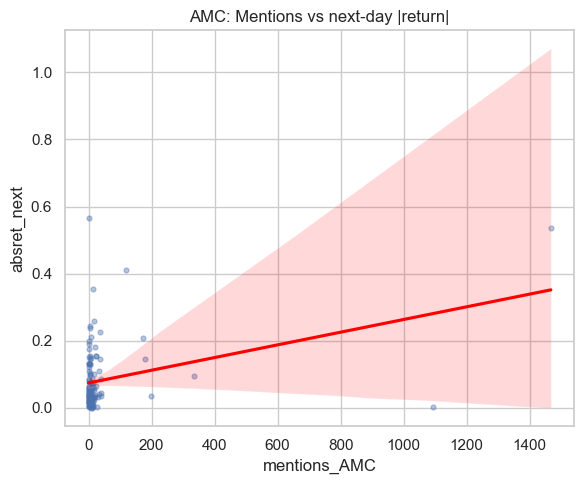

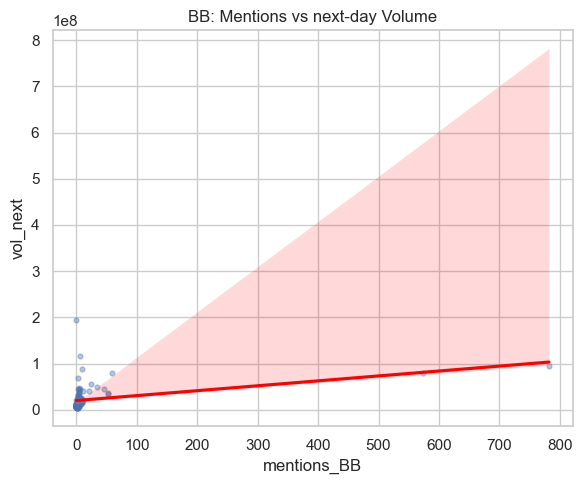

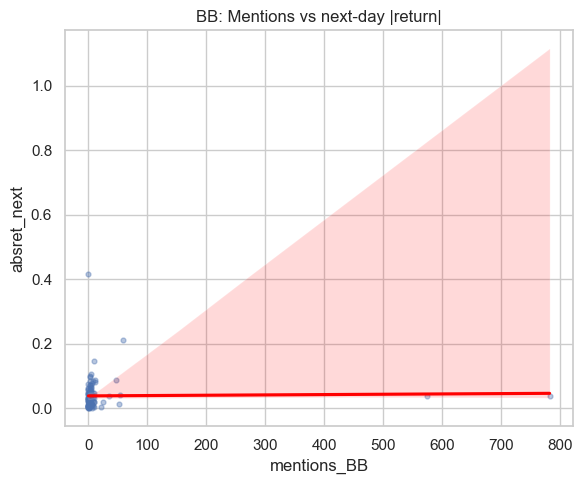

In [9]:
# If cells were run out of order, joined may not contain all tickers.
# This loop uses whatever exists in `joined` and will clearly warn if something is missing.
missing = [t for t in TICKERS if t not in joined]
if missing:
    print("Warning: missing in joined ->", missing)
    print("Available joined keys ->", list(joined.keys()))

for t, df0 in joined.items():
    mention_col = f"mentions_{t}"
    required = [mention_col, "vol_next", "absret_next"]
    if not all(c in df0.columns for c in required):
        print(f"Skipping {t}: missing columns", [c for c in required if c not in df0.columns])
        continue

    df = df0.dropna(subset=required)

    plt.figure(figsize=(6, 5))
    sns.regplot(
        data=df,
        x=mention_col,
        y="vol_next",
        scatter_kws={"s": 12, "alpha": 0.4},
        line_kws={"color": "red"},
    )
    plt.title(f"{t}: Mentions vs next-day Volume")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{t}_mentions_vs_nextday_volume.png", dpi=160)
    plt.show()

    plt.figure(figsize=(6, 5))
    sns.regplot(
        data=df,
        x=mention_col,
        y="absret_next",
        scatter_kws={"s": 12, "alpha": 0.4},
        line_kws={"color": "red"},
    )
    plt.title(f"{t}: Mentions vs next-day |return|")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{t}_mentions_vs_nextday_abs_return.png", dpi=160)
    plt.show()

## 8) Hypothesis tests

We test whether **high-attention days** (top 25% by `mentions_<TICKER>`) have larger **next-day trading volume** and **next-day volatility**.

- Two-sample comparison: Mann–Whitney U (non-parametric)
- Monotonic association: Spearman correlation

In [10]:
def cliff_delta(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x)
    y = np.asarray(y)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    gt = 0
    lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
    return (gt - lt) / (len(x) * len(y))


def safe_mw(a: pd.Series, b: pd.Series):
    if len(a) == 0 or len(b) == 0:
        return (np.nan, np.nan)
    return stats.mannwhitneyu(a, b, alternative="two-sided")


def safe_spearman(x: pd.Series, y: pd.Series):
    if len(x) < 3 or len(y) < 3:
        return (np.nan, np.nan)
    return stats.spearmanr(x, y)


results = []

for t in TICKERS:
    mention_col = f"mentions_{t}"
    df = joined[t].dropna(subset=[mention_col, "vol_next", "absret_next"])

    q75 = df[mention_col].quantile(0.75)
    high = df[df[mention_col] >= q75]
    low = df[df[mention_col] < q75]

    # H1: next-day volume differs between high vs low attention
    stat1, p1 = safe_mw(high["vol_next"], low["vol_next"])
    cd1 = cliff_delta(high["vol_next"].to_numpy(), low["vol_next"].to_numpy())

    # H2: next-day abs return differs
    stat2, p2 = safe_mw(high["absret_next"], low["absret_next"])
    cd2 = cliff_delta(high["absret_next"].to_numpy(), low["absret_next"].to_numpy())

    # H3: Spearman correlations
    rho_v, p_v = safe_spearman(df[mention_col], df["vol_next"])
    rho_a, p_a = safe_spearman(df[mention_col], df["absret_next"])

    results += [
        {
            "hypothesis": "H1_high_mentions_increase_nextday_volume",
            "ticker": t,
            "n": len(df),
            "statistic": float(stat1),
            "p_value": float(p1),
            "n_high": len(high),
            "n_low": len(low),
            "cliffs_delta": float(cd1),
        },
        {
            "hypothesis": "H2_high_mentions_increase_nextday_abs_return",
            "ticker": t,
            "n": len(df),
            "statistic": float(stat2),
            "p_value": float(p2),
            "n_high": len(high),
            "n_low": len(low),
            "cliffs_delta": float(cd2),
        },
        {
            "hypothesis": "H3_spearman_mentions_vs_nextday_volume",
            "ticker": t,
            "n": len(df),
            "statistic": float(rho_v),
            "p_value": float(p_v),
        },
        {
            "hypothesis": "H3b_spearman_mentions_vs_nextday_abs_return",
            "ticker": t,
            "n": len(df),
            "statistic": float(rho_a),
            "p_value": float(p_a),
        },
    ]

hyp = pd.DataFrame(results)
hyp.to_csv(TABLE_DIR / "hypothesis_tests.csv", index=False)

hyp

,hypothesis,ticker,n,statistic,p_value,n_high,n_low,cliffs_delta
0,H1_high_mentions_increase_nextday_volume,GME,122,2631.000000,7.253062e-13,31.0,91.0,0.865296
1,H2_high_mentions_increase_nextday_abs_return,GME,122,1790.000000,2.582563e-02,31.0,91.0,0.269054
2,H3_spearman_mentions_vs_nextday_volume,GME,122,0.760762,2.814794e-24,NaN,NaN,NaN
3,H3b_spearman_mentions_vs_nextday_abs_return,GME,122,0.323892,2.733911e-04,NaN,NaN,NaN
4,H1_high_mentions_increase_nextday_volume,AMC,122,2205.000000,8.603717e-06,32.0,90.0,0.531250
5,H2_high_mentions_increase_nextday_abs_return,AMC,122,1815.000000,2.928085e-02,32.0,90.0,0.260417
6,H3_spearman_mentions_vs_nextday_volume,AMC,122,0.451873,1.746204e-07,NaN,NaN,NaN
7,H3b_spearman_mentions_vs_nextday_abs_return,AMC,122,0.142180,1.182380e-01,NaN,NaN,NaN
8,H1_high_mentions_increase_nextday_volume,BB,122,2674.000000,7.265100e-11,35.0,87.0,0.756322
9,H2_high_mentions_increase_nextday_abs_return,BB,122,1760.000000,1.797561e-01,35.0,87.0,0.155993


## 9) What to submit for the 14 April checkpoint

- The notebook (`dsa210_analysis.ipynb`) showing **every step** and generating plots/tests
- The generated outputs under `outputs/`
- `REPORT_14APR_EDA_HYPOTHESIS.md` (short written summary)
- `requirements.txt` + `README.md` for reproducibility